In [ ]:
!wget ht
tps://raw.githubusercontent.com/nagarajuekkirala/ML-Workshop/refs/heads/main/swiggy_cleaned.csv

--2025-10-15 10:35:02--  https://raw.githubusercontent.com/nagarajuekkirala/ML-Workshop/refs/heads/main/swiggy_cleaned.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8083490 (7.7M) [text/plain]
Saving to: ‘swiggy_cleaned.csv’

swiggy_cleaned.csv  100%[===================>]   7.71M  --.-KB/s    in 0.02s   

2025-10-15 10:35:02 (381 MB/s) - ‘swiggy_cleaned.csv’ saved [8083490/8083490]



In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv('/content/swiggy_cleaned.csv')
data

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393


In [ ]:
data.shape

(45502, 26)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45502 entries, 0 to 45501
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rider_id              45502 non-null  object 
 1   age                   43648 non-null  float64
 2   ratings               43594 non-null  float64
 3   restaurant_latitude   41872 non-null  float64
 4   restaurant_longitude  41872 non-null  float64
 5   delivery_latitude     41872 non-null  float64
 6   delivery_longitude    41872 non-null  float64
 7   order_date            45502 non-null  object 
 8   weather               44977 non-null  object 
 9   traffic               44992 non-null  object 
 10  vehicle_condition     45502 non-null  int64  
 11  type_of_order         45502 non-null  object 
 12  type_of_vehicle       45502 non-null  object 
 13  multiple_deliveries   44509 non-null  float64
 14  festival              45274 non-null  object 
 15  city_type          

In [ ]:
data['order_month'].unique()

array([3, 4, 2])

In [ ]:
data=data.drop(columns=['rider_id','restaurant_latitude','restaurant_longitude', 'delivery_latitude', 'delivery_longitude', 'order_date','order_day','order_month', 'order_time_hour','order_time_of_day'])
data.head()

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day_of_week,is_weekend,pickup_time_minutes,distance
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,saturday,1,15.0,3.025149
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,friday,0,5.0,20.183530
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,saturday,1,15.0,1.552758
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,tuesday,0,10.0,7.790401
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,saturday,1,15.0,6.210138


In [ ]:
data.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [ ]:
#data cleaing
data.isna().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [ ]:
data.isna().sum().sum()

np.int64(12486)

In [ ]:
data['age'].isna().sum()

np.int64(1854)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


<Axes: ylabel='age'>

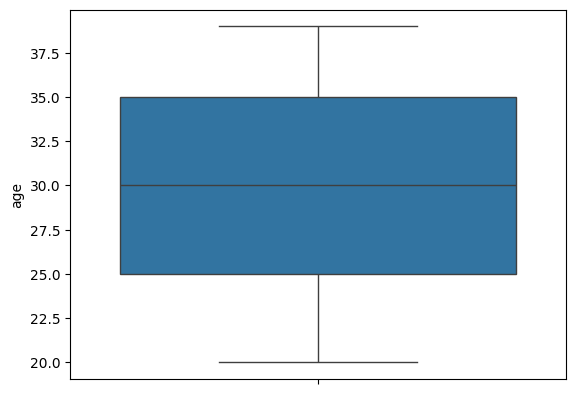

In [ ]:
sns.boxplot(data=data,y='age')

In [ ]:
m=data['age'].mean()
data['age']=data['age'].fillna(m)

In [ ]:
data['age'].isna().sum()

np.int64(0)

In [ ]:
data['weather'].unique()

array(['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan],
      dtype=object)

In [ ]:
mo=data['weather'].mode()

In [ ]:
data['weather']=data['weather'].fillna('fog')
data['weather'].isna().sum()

np.int64(0)

In [ ]:
num_cols=data.select_dtypes(['float64','int64']).columns

In [ ]:
for col in num_cols:
  data[col]=data[col].fillna(data[col].mean())

In [ ]:
cat_cols=data.select_dtypes(['object']).columns

In [ ]:
for col in cat_cols:
  data[col]=data[col].fillna(data[col].mode())

In [ ]:
data.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,228
city_type,1198


In [ ]:
data.duplicated().sum()

np.int64(0)